# K-Means Clustering

In K-Means Clustering we have to choose the value of 'K' very accurately by looking at the Within Sum of Squares (WSS).

In [87]:
import pandas as pd
import numpy as np
import seaborn as sns
import os
from sklearn.cluster import KMeans 
import matplotlib.pyplot as plt
%matplotlib inline

In [88]:
path = r"D:\GLIM course\Term-3\Business Analytics\Assignment"
os.chdir(path)
df = pd.read_excel('Clustering Clean Ads_Data.xlsx')
df.head()

,Timestamp,InventoryType,Ad - Length,Ad- Width,Ad Size,Ad Type,Platform,Device Type,Format,Available_Impressions,Matched_Queries,Impressions,Clicks,Spend,Fee,Revenue,CTR,CPM,CPC
0,2020-9-2-17,Format1,300,250,75000,Inter222,Video,Desktop,Display,1806,325,323,1,0.0,0.35,0.0,0.0031,0.0,0.0
1,2020-9-2-18,Format1,300,250,75000,Inter223,Web,Mobile,Display,1979,384,380,0,0.0,0.35,0.0,0.0000,0.0,NaN
2,2020-9-3-16,Format6,336,250,84000,Inter217,Web,Desktop,Video,1566,298,297,0,0.0,0.35,0.0,0.0000,0.0,NaN
3,2020-9-3-2,Format1,300,250,75000,Inter224,Web,Desktop,Display,643,103,102,0,0.0,0.35,0.0,0.0000,0.0,NaN
4,2020-9-3-13,Format1,300,250,75000,Inter225,Video,Mobile,Display,1550,347,345,0,0.0,0.35,0.0,0.0000,0.0,NaN


In [89]:
df.tail()

,Timestamp,InventoryType,Ad - Length,Ad- Width,Ad Size,Ad Type,Platform,Device Type,Format,Available_Impressions,Matched_Queries,Impressions,Clicks,Spend,Fee,Revenue,CTR,CPM,CPC
25852,2020-10-1-5,Format5,720,300,216000,Inter222,Video,Desktop,Video,1,1,1,0,0.01,0.35,0.0065,NaN,NaN,NaN
25853,2020-11-18-2,Format4,120,600,72000,inter230,Video,Mobile,Video,7,1,1,1,0.07,0.35,0.0455,NaN,NaN,NaN
25854,2020-9-14-0,Format5,720,300,216000,Inter221,App,Mobile,Video,2,2,2,1,0.09,0.35,0.0585,NaN,NaN,NaN
25855,2020-9-30-4,Format7,300,600,180000,Inter228,Video,Mobile,Display,1,1,1,0,0.01,0.35,0.0065,NaN,NaN,NaN
25856,2020-10-17-3,Format5,720,300,216000,Inter225,Video,Mobile,Display,1,1,1,0,0.01,0.35,0.0065,NaN,NaN,NaN


Step:1 Loading data and Basic data analysis

In [90]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
df.describe(include='all')

Number of rows: 25857
Number of columns: 19


,Timestamp,InventoryType,Ad - Length,Ad- Width,Ad Size,Ad Type,Platform,Device Type,Format,Available_Impressions,Matched_Queries,Impressions,Clicks,Spend,Fee,Revenue,CTR,CPM,CPC
count,25857,25857,25857.000000,25857.000000,25857.000000,25857,25857,25857,25857,2.585700e+04,2.585700e+04,2.585700e+04,25857.000000,25857.000000,25857.000000,25857.000000,19392.000000,19392.000000,18330.000000
unique,2018,7,NaN,NaN,NaN,14,3,2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,2020-9-3-22,Format4,NaN,NaN,NaN,Inter217,Video,Mobile,Display,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,13,7218,NaN,NaN,NaN,1849,11077,16621,12929,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,390.431218,332.182774,99683.276482,NaN,NaN,NaN,NaN,2.169621e+06,1.155322e+06,1.107525e+06,9525.881386,2414.473115,0.336729,1716.548955,0.069627,7.252900,0.351061
std,NaN,NaN,230.696051,194.260924,62640.685612,NaN,NaN,NaN,NaN,4.542680e+06,2.407244e+06,2.326648e+06,16721.686071,3932.835240,0.030540,2993.025498,0.074970,6.538314,0.343334
min,NaN,NaN,120.000000,70.000000,33600.000000,NaN,NaN,NaN,NaN,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.210000,0.000000,0.000000,0.000000,0.000000
25%,NaN,NaN,120.000000,250.000000,72000.000000,NaN,NaN,NaN,NaN,9.133000e+03,5.451000e+03,2.558000e+03,305.000000,36.030000,0.350000,23.420000,0.002400,1.630000,0.090000
50%,NaN,NaN,300.000000,300.000000,75000.000000,NaN,NaN,NaN,NaN,3.309680e+05,1.894490e+05,1.621620e+05,3457.000000,1173.660000,0.350000,762.880000,0.007700,3.035000,0.160000
75%,NaN,NaN,720.000000,600.000000,84000.000000,NaN,NaN,NaN,NaN,2.208484e+06,1.008171e+06,9.496930e+05,10681.000000,2692.280000,0.350000,1749.982000,0.128300,12.220000,0.570000


Step 2: Replacing missing values

In [91]:
print("No of missing values:")
df[['CPM', 'CPC', 'CTR']].isnull().sum()

No of missing values:


CPM    6465
CPC    7527
CTR    6465
dtype: int64

In [92]:
df['CPM'] = np.where(df['Impressions'] == 0, np.nan, (df['Spend'] / df['Impressions']) * 1000)
df['CPC'] = np.where(df['Clicks'] == 0, np.nan, df['Spend'] / df['Clicks'])
df['CTR'] = np.where(df['Impressions'] == 0, np.nan, (df['Clicks'] / df['Impressions']) * 100)

In [93]:
df.describe()

,Ad - Length,Ad- Width,Ad Size,Available_Impressions,Matched_Queries,Impressions,Clicks,Spend,Fee,Revenue,CTR,CPM,CPC
count,25857.000000,25857.000000,25857.000000,2.585700e+04,2.585700e+04,2.585700e+04,25857.000000,25857.000000,25857.000000,25857.000000,25638.000000,25638.000000,23066.000000
mean,390.431218,332.182774,99683.276482,2.169621e+06,1.155322e+06,1.107525e+06,9525.881386,2414.473115,0.336729,1716.548955,7.566257,7.588959,0.336678
std,230.696051,194.260924,62640.685612,4.542680e+06,2.407244e+06,2.326648e+06,16721.686071,3932.835240,0.030540,2993.025498,9.141279,8.938999,0.341253
min,120.000000,70.000000,33600.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.210000,0.000000,0.000000,0.000000,0.000000
25%,120.000000,250.000000,72000.000000,9.133000e+03,5.451000e+03,2.558000e+03,305.000000,36.030000,0.350000,23.420000,0.236835,1.589608,0.089736
50%,300.000000,300.000000,75000.000000,3.309680e+05,1.894490e+05,1.621620e+05,3457.000000,1173.660000,0.350000,762.880000,0.766600,3.333333,0.139347
75%,720.000000,600.000000,84000.000000,2.208484e+06,1.008171e+06,9.496930e+05,10681.000000,2692.280000,0.350000,1749.982000,13.094676,12.491089,0.546242
max,728.000000,600.000000,216000.000000,2.759286e+07,1.470202e+07,1.419477e+07,143049.000000,26931.870000,0.350000,21276.180000,200.000000,715.000000,7.264000


In [94]:
print("no of missing values after augmentation")
df[['CPM', 'CPC', 'CTR']].isnull().sum()

no of missing values after augmentation


CPM     219
CPC    2791
CTR     219
dtype: int64

In [95]:
df[['CPM', 'CPC', 'CTR']] = df[['CPM', 'CPC', 'CTR']].fillna(0)
print("no of missing values after replacement")
df[['CPM', 'CPC', 'CTR']].isnull().sum()

no of missing values after replacement


CPM    0
CPC    0
CTR    0
dtype: int64

Not all missing values are replaced. It means the function successfully imputed some missing values, but some rows cannot be calculated using the formula as currently written.

The most common reason is that the denominator is 0 or missing.

For example:

CPM → impressions = 0 or missing
CPC → clicks = 0 or missing
CTR → impressions = 0 or missing

Our function deliberately avoided dividing by zero, so those rows remained NaN

Step 3: Outliers

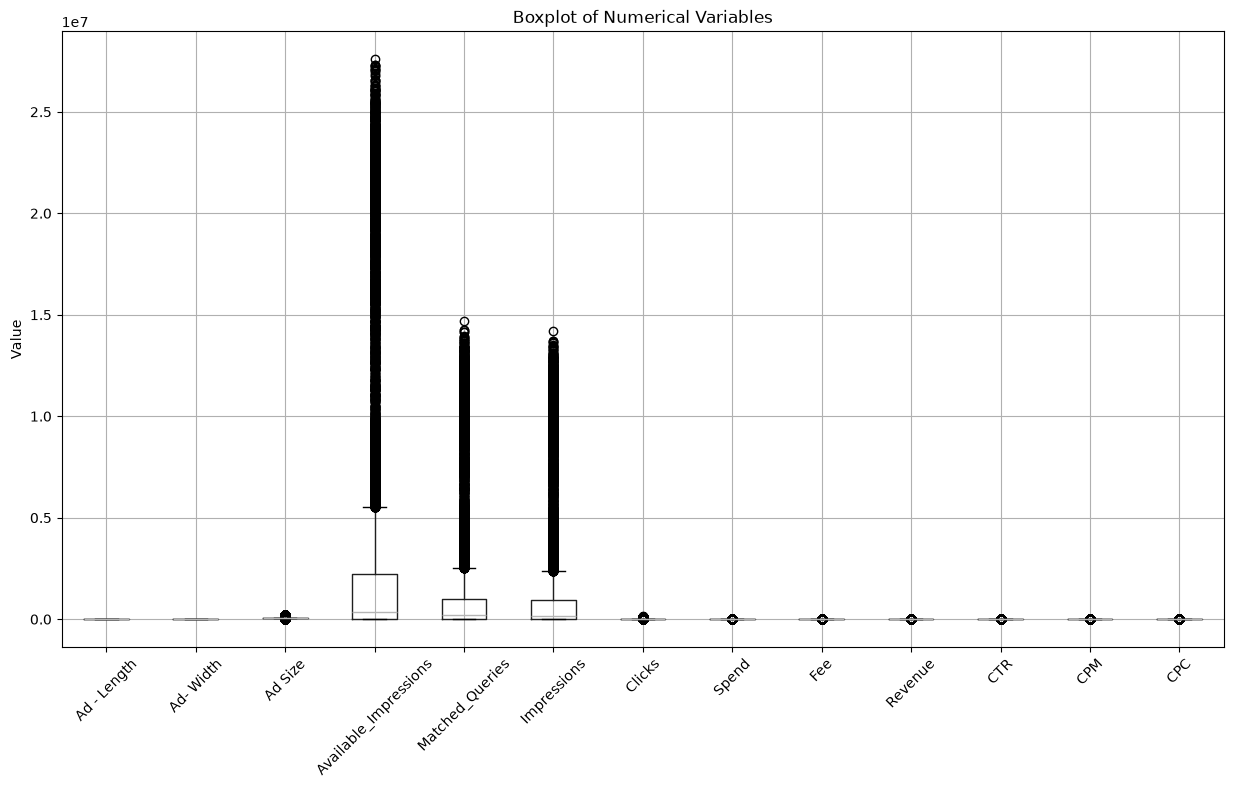

In [96]:
df.describe().T
numeric_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, 8))
df[numeric_cols].boxplot()
plt.xticks(rotation=45)
plt.title("Boxplot of Numerical Variables")
plt.ylabel("Value")
plt.show()

In [97]:
outlier_summary = []

for col in numeric_cols:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    
    outlier_summary.append({
        'Variable': col,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Outlier Count': len(outliers),
        'Outlier %': (len(outliers) / len(df)) * 100
    })

outlier_summary = pd.DataFrame(outlier_summary)

outlier_summary

,Variable,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier %
0,Ad - Length,120.000000,7.200000e+02,6.000000e+02,-7.800000e+02,1.620000e+03,0,0.000000
1,Ad- Width,250.000000,6.000000e+02,3.500000e+02,-2.750000e+02,1.125000e+03,0,0.000000
2,Ad Size,72000.000000,8.400000e+04,1.200000e+04,5.400000e+04,1.020000e+05,9450,36.547163
3,Available_Impressions,9133.000000,2.208484e+06,2.199351e+06,-3.289894e+06,5.507510e+06,2809,10.863596
4,Matched_Queries,5451.000000,1.008171e+06,1.002720e+06,-1.498629e+06,2.512251e+06,3464,13.396759
5,Impressions,2558.000000,9.496930e+05,9.471350e+05,-1.418144e+06,2.370396e+06,3546,13.713888
6,Clicks,305.000000,1.068100e+04,1.037600e+04,-1.525900e+04,2.624500e+04,2093,8.094520
7,Spend,36.030000,2.692280e+03,2.656250e+03,-3.948345e+03,6.676655e+03,2459,9.509997
8,Fee,0.350000,3.500000e-01,0.000000e+00,3.500000e-01,3.500000e-01,5925,22.914491
9,Revenue,23.420000,1.749982e+03,1.726562e+03,-2.566423e+03,4.339825e+03,2626,10.155857


The IQR method identified a substantial number of potential outliers in variables such as Ad Size, Available Impressions, Matched Queries, Impressions, Spend and Revenue. However, these observations may represent genuine differences in advertising scale and campaign performance rather than data-entry errors. Removing them could eliminate meaningful business segments and distort the clustering results. Therefore, the observations will be retained rather than deleted. Their effect will instead be controlled through appropriate scaling before clustering.

In [99]:
from sklearn.preprocessing import StandardScaler
df_augmented = df.copy()
df_augmented = df_augmented.drop(df.select_dtypes(exclude='number').columns.tolist(), axis=1)
df_augmented.head()

,Ad - Length,Ad- Width,Ad Size,Available_Impressions,Matched_Queries,Impressions,Clicks,Spend,Fee,Revenue,CTR,CPM,CPC
0,300,250,75000,1806,325,323,1,0.0,0.35,0.0,0.309598,0.0,0.0
1,300,250,75000,1979,384,380,0,0.0,0.35,0.0,0.000000,0.0,0.0
2,336,250,84000,1566,298,297,0,0.0,0.35,0.0,0.000000,0.0,0.0
3,300,250,75000,643,103,102,0,0.0,0.35,0.0,0.000000,0.0,0.0
4,300,250,75000,1550,347,345,0,0.0,0.35,0.0,0.000000,0.0,0.0


For the clustering model, we exclude CPC, CPM and CTR from the clustering variables and use the underlying variables (Impressions, Clicks, Spend, etc.) instead. We can still retain CPM/CPC/CTR for cluster profiling and business interpretation.

In [100]:
# Let us check the scaled data.
data_scaled = pd.DataFrame(StandardScaler().fit_transform(df_augmented),columns=df_augmented.columns)

Step 4: Hierarchical Clustering

In [101]:
from scipy.cluster.hierarchy import dendrogram, linkage
ward_link = linkage(data_scaled,method = 'ward',metric='euclidean')
ward_link

array([[1.50000000e+01, 1.86600000e+03, 0.00000000e+00, 2.00000000e+00],
       [1.06000000e+02, 8.93000000e+02, 0.00000000e+00, 2.00000000e+00],
       [1.96900000e+03, 2.55000000e+03, 0.00000000e+00, 2.00000000e+00],
       ...,
       [5.17040000e+04, 5.17080000e+04, 2.97863978e+02, 1.73370000e+04],
       [5.17090000e+04, 5.17100000e+04, 3.24160974e+02, 2.46940000e+04],
       [5.16960000e+04, 5.17110000e+04, 4.80360193e+02, 2.58570000e+04]],
      shape=(25856, 4))

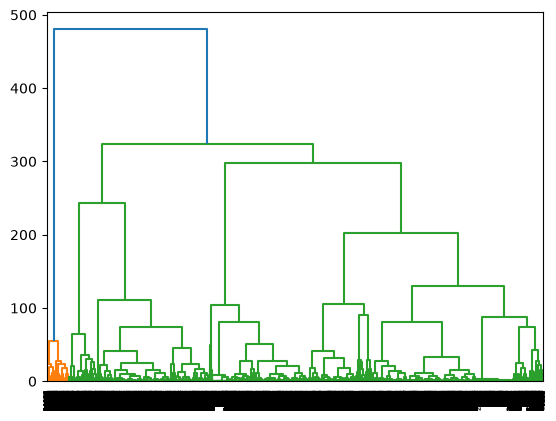

In [102]:
from scipy.cluster.hierarchy import dendrogram, linkage
warddend = dendrogram(ward_link)

In [103]:
from scipy.cluster.hierarchy import fcluster
clusters = fcluster(ward_link, 6, criterion='maxclust')
clusters

array([6, 6, 6, ..., 4, 6, 4], shape=(25857,), dtype=int32)

In [104]:
df['Hier_clusters'] = clusters
df.head()

,Timestamp,InventoryType,Ad - Length,Ad- Width,Ad Size,Ad Type,Platform,Device Type,Format,Available_Impressions,Matched_Queries,Impressions,Clicks,Spend,Fee,Revenue,CTR,CPM,CPC,Hier_clusters
0,2020-9-2-17,Format1,300,250,75000,Inter222,Video,Desktop,Display,1806,325,323,1,0.0,0.35,0.0,0.309598,0.0,0.0,6
1,2020-9-2-18,Format1,300,250,75000,Inter223,Web,Mobile,Display,1979,384,380,0,0.0,0.35,0.0,0.000000,0.0,0.0,6
2,2020-9-3-16,Format6,336,250,84000,Inter217,Web,Desktop,Video,1566,298,297,0,0.0,0.35,0.0,0.000000,0.0,0.0,6
3,2020-9-3-2,Format1,300,250,75000,Inter224,Web,Desktop,Display,643,103,102,0,0.0,0.35,0.0,0.000000,0.0,0.0,6
4,2020-9-3-13,Format1,300,250,75000,Inter225,Video,Mobile,Display,1550,347,345,0,0.0,0.35,0.0,0.000000,0.0,0.0,6


In [107]:
df2 = df[['CPM','CPC','CTR','Spend','Clicks','Revenue','Hier_clusters', 'Device Type']]
df_clust1 = df2.groupby(['Hier_clusters','Device Type']).mean()
df_clust1 = df_clust1.reset_index()
round(df_clust1,2)

,Hier_clusters,Device Type,CPM,CPC,CTR,Spend,Clicks,Revenue
0,1,Desktop,1.65,0.86,0.19,17169.48,20046.00,13223.65
1,1,Mobile,1.66,0.86,0.19,16983.75,19840.56,13075.87
2,2,Desktop,15.45,0.11,13.79,7012.06,65642.89,5033.94
3,2,Mobile,15.37,0.11,13.72,7027.11,65559.79,5046.96
4,3,Desktop,14.45,0.10,16.08,214.15,2006.39,139.20
5,3,Mobile,14.71,0.10,16.03,215.35,1951.75,139.98
6,4,Desktop,10.21,0.07,11.57,1003.60,11743.26,653.57
7,4,Mobile,10.38,0.07,11.72,997.01,11446.91,649.35
8,5,Desktop,1.61,0.79,0.22,4859.78,7062.93,3358.60
9,5,Mobile,1.60,0.80,0.22,4926.43,6983.02,3410.60


Step 5: Elbow plot

In [108]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(data_scaled)
    wcss.append(kmeans.inertia_)

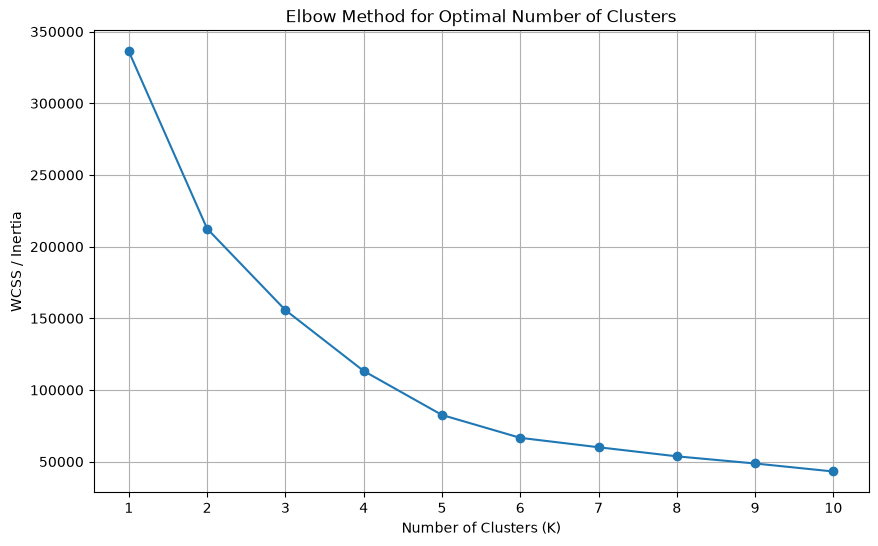

In [109]:
plt.figure(figsize=(10, 6))

plt.plot(range(1, 11), wcss, marker='o')

plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS / Inertia')
plt.title('Elbow Method for Optimal Number of Clusters')

plt.xticks(range(1, 11))
plt.grid(True)

plt.show()

In [110]:
for k, value in zip(range(1, 11), wcss):
    print(f"K = {k}: WCSS = {value:.2f}")

K = 1: WCSS = 336141.00
K = 2: WCSS = 212507.05
K = 3: WCSS = 155722.18
K = 4: WCSS = 113259.49
K = 5: WCSS = 82561.84
K = 6: WCSS = 66614.55
K = 7: WCSS = 60049.63
K = 8: WCSS = 53712.12
K = 9: WCSS = 48714.78
K = 10: WCSS = 43129.87


Step 6: Silhouette Scores

In [111]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):
    
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    cluster_labels = kmeans.fit_predict(data_scaled)
    
    score = silhouette_score(data_scaled, cluster_labels)
    
    silhouette_scores.append(score)

In [112]:
for k, score in zip(range(2, 11), silhouette_scores):
    print(f"K = {k}: Silhouette Score = {score:.4f}")

K = 2: Silhouette Score = 0.6264
K = 3: Silhouette Score = 0.3482
K = 4: Silhouette Score = 0.4679
K = 5: Silhouette Score = 0.5163
K = 6: Silhouette Score = 0.4988
K = 7: Silhouette Score = 0.5064
K = 8: Silhouette Score = 0.4929
K = 9: Silhouette Score = 0.5123
K = 10: Silhouette Score = 0.5142


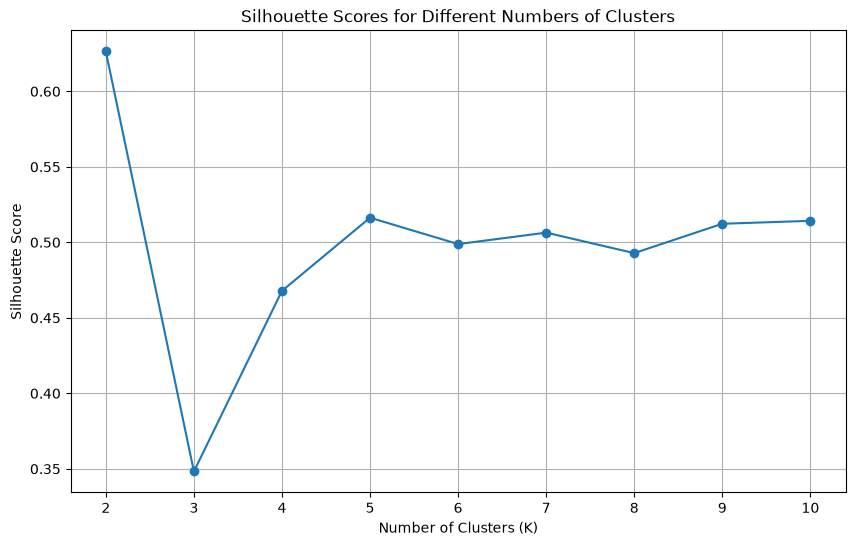

In [113]:
plt.figure(figsize=(10, 6))

plt.plot(
    range(2, 11),
    silhouette_scores,
    marker='o'
)

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores for Different Numbers of Clusters')

plt.xticks(range(2, 11))
plt.grid(True)

plt.show()

In [114]:
best_k_silhouette = range(2, 11)[np.argmax(silhouette_scores)]
best_score = max(silhouette_scores)

print("Optimal K based on Silhouette Score:", best_k_silhouette)
print("Highest Silhouette Score:", round(best_score, 4))

Optimal K based on Silhouette Score: 2
Highest Silhouette Score: 0.6264


Step 7: K means

In [115]:
k_means = KMeans(n_clusters = 6)
k_means.fit(data_scaled)
k_means.inertia_
labels = k_means.labels_
labels

array([1, 1, 1, ..., 0, 3, 0], shape=(25857,), dtype=int32)

In [116]:
df["Clus_kmeans"] = labels
df.tail()

,Timestamp,InventoryType,Ad - Length,Ad- Width,Ad Size,Ad Type,Platform,Device Type,Format,Available_Impressions,...,Impressions,Clicks,Spend,Fee,Revenue,CTR,CPM,CPC,Hier_clusters,Clus_kmeans
25852,2020-10-1-5,Format5,720,300,216000,Inter222,Video,Desktop,Video,1,...,1,0,0.01,0.35,0.0065,0.0,10.0,0.00,4,0
25853,2020-11-18-2,Format4,120,600,72000,inter230,Video,Mobile,Video,7,...,1,1,0.07,0.35,0.0455,100.0,70.0,0.07,4,3
25854,2020-9-14-0,Format5,720,300,216000,Inter221,App,Mobile,Video,2,...,2,1,0.09,0.35,0.0585,50.0,45.0,0.09,4,0
25855,2020-9-30-4,Format7,300,600,180000,Inter228,Video,Mobile,Display,1,...,1,0,0.01,0.35,0.0065,0.0,10.0,0.00,6,3
25856,2020-10-17-3,Format5,720,300,216000,Inter225,Video,Mobile,Display,1,...,1,0,0.01,0.35,0.0065,0.0,10.0,0.00,4,0


Now that we have created a new column of clusters, let us export this into a .csv file.

In [117]:
df.to_csv('KMeans_Output.csv')

In [118]:
df = df.drop('Hier_clusters', axis=1)

Now, let us compare the different clusters with the average values and try to interpret the problem.

In [124]:
df3 = df[['CPM','CPC','CTR','Spend','Clicks','Revenue','Clus_kmeans']]
df_clust2 = df3.groupby('Clus_kmeans').mean()
df_clust2 = df_clust2.reset_index()
round(df_clust2,2)

,Clus_kmeans,CPM,CPC,CTR,Spend,Clicks,Revenue
0,0,9.89,0.07,11.17,1005.02,11618.03,654.54
1,1,1.77,0.32,0.87,912.74,2798.70,593.37
2,2,1.68,0.88,0.19,16378.39,18872.71,12573.91
3,3,14.61,0.10,15.79,380.91,3265.53,249.94
4,4,1.63,0.78,0.23,4174.02,6179.77,2840.37
5,5,14.94,0.11,13.79,7432.13,70563.26,5362.60


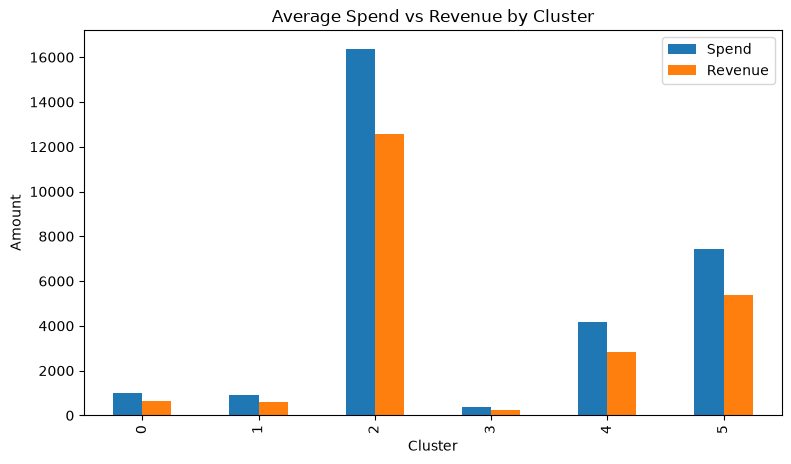

In [129]:
cluster_business = df.groupby('Clus_kmeans')[['Spend','Revenue']].mean().reset_index()

cluster_business.plot(
    x='Clus_kmeans',
    y=['Spend','Revenue'],
    kind='bar',
    figsize=(9,5)
)

plt.title('Average Spend vs Revenue by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Amount')
plt.show()

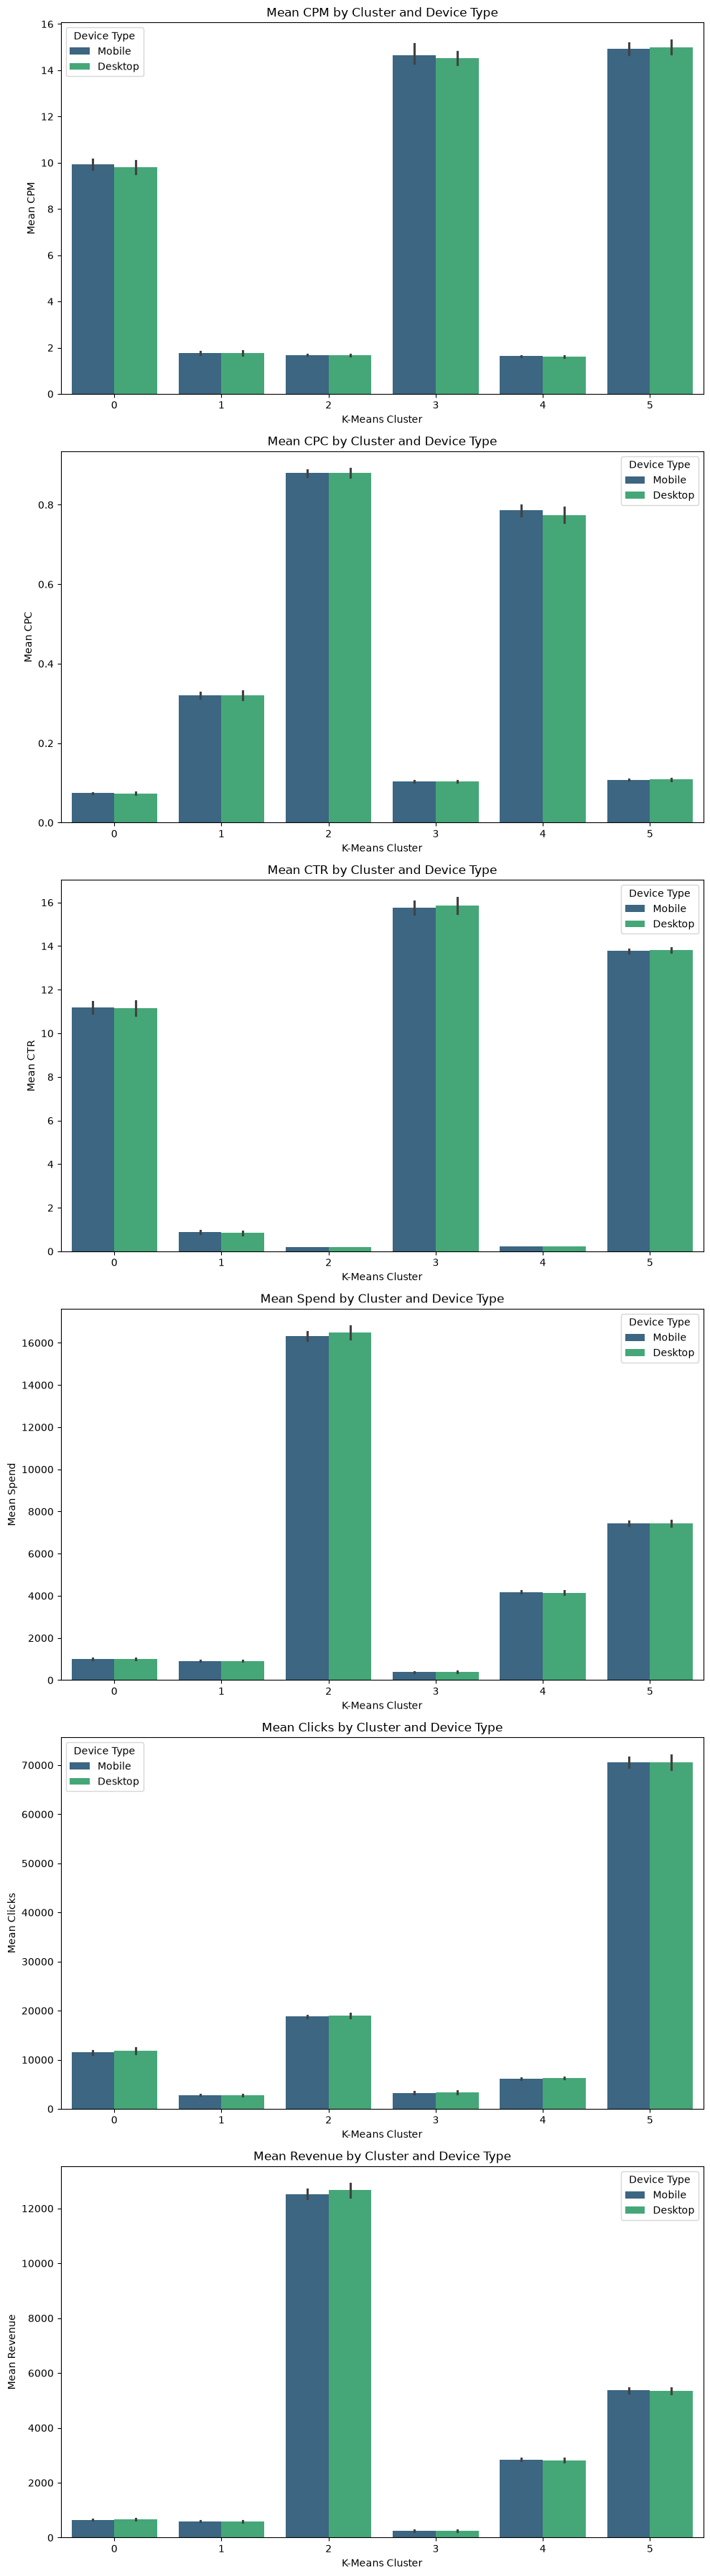

In [132]:
df_clust2_reset = df.reset_index()

# Define the metrics to plot
metrics_to_plot = ['CPM', 'CPC', 'CTR', 'Spend', 'Clicks', 'Revenue']

# Create bar plots for each metric
fig, axes = plt.subplots(nrows=len(metrics_to_plot), ncols=1, figsize=(10, 6 * len(metrics_to_plot)))
axes = axes.flatten()

for i, metric in enumerate(metrics_to_plot):
    sns.barplot(x='Clus_kmeans', y=metric, hue='Device Type', data=df_clust2_reset, ax=axes[i], palette='viridis')
    axes[i].set_title(f'Mean {metric} by Cluster and Device Type')
    axes[i].set_xlabel('K-Means Cluster')
    axes[i].set_ylabel(f'Mean {metric}')
    axes[i].ticklabel_format(style='plain', axis='y') # Prevent scientific notation for y-axis
    axes[i].legend(title='Device Type')

plt.tight_layout()

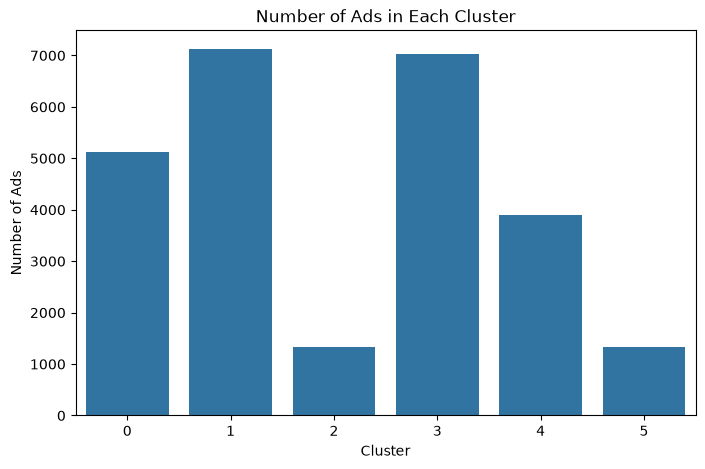

In [133]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Clus_kmeans')
plt.title('Number of Ads in Each Cluster')
plt.xlabel('Cluster')
plt.ylabel('Number of Ads')
plt.show()

Let us check the frequency of the occurence of the clusters for each individual cluster.